# 23. Hierarchical co-design for a Formula 1 season (precompute-then-DP)

This notebook reproduces, in the framework's vocabulary, the seasonal co-design of Neumann, Habermacher, Fieni, Cerofolini, Zardini, and Onder, *"Hierarchical Co-Design for Multi-Race Strategy Optimization in Formula 1"* (ITSC 2026). It is the canonical **precompute-then-DP** structure that motivated the `precompute_catalog` / `dp_over_catalog` helpers.

The idea is a clean separation into two layers:

1. **Race-level co-design** (uses the MCDP framework). For each track, battery size, and *incoming battery age*, a `CatalogDP` over energy-deployment strategies emits a Pareto front of `(race_time, wear_increment)`: deploying more electrical energy lowers race time but ages the battery faster, and an aged pack deploys less effectively. This front is solved **once** and frozen.

2. **Season-level dynamic program** (a scalar maximisation MDP). The state is a vector `(w1, w2, ex)`: the fractional wear of the two regulation-permitted battery units plus a flag recording whether a replacement penalty has been incurred. Each race the controls are which unit to run, which frozen implementation (deployment strategy) to pick, and whether to install a fresh unit (a grid penalty: 10 places for the first replacement, 5 for each later one). Race time maps to expected championship points through a time-gap and grid-penalty model integrated against the FIA points table. The DP maximises the season's total expected points.

No co-design solve happens inside the season sweep, which is exactly what distinguishes precompute-then-DP from the re-solving `solve_sequential`.


## Imports and module load

In [1]:
import importlib.util, os, sys
PROJECT_ROOT = os.path.abspath('.')
sys.path.insert(0, PROJECT_ROOT)

_spec = importlib.util.spec_from_file_location(
    'f1', os.path.join(PROJECT_ROOT, 'examples', '23_formula1_season.py'))
f1 = importlib.util.module_from_spec(_spec)
sys.modules['f1'] = f1   # register before exec so @dataclass(frozen=True) resolves
_spec.loader.exec_module(f1)

print("Season:", ", ".join(t.name for t in f1.SEASON))
print("Batteries:", ", ".join(f"{k} ({v} MJ)" for k, v in f1.BATTERIES.items()))
print(f"Wear limit {f1.WEAR_MAX:.0%}, deploy strategies {f1.DEPLOY_STRATEGIES}")
print("FIA points P1..P10:", [f1.FIA_POINTS[p] for p in range(1, 11)])


Season: Monza, Silverstone, Monaco, Spa, Hungaroring, Suzuka, Interlagos, Zandvoort
Batteries: 3MJ (3.0 MJ), 4MJ (4.0 MJ)
Wear limit 30%, deploy strategies [0.0, 0.25, 0.5, 0.75, 1.0]
FIA points P1..P10: [25, 18, 15, 12, 10, 8, 6, 4, 2, 1]


## Layer 1: the race Pareto front (the paper's Fig. 1)

Each deployment strategy is a `CatalogDP` entry emitting `(race_time, wear)`. `precompute_catalog` returns the Pareto front through a genuine MCDP solve. Faster race times cost more battery wear, so the whole set is non-dominated, the trade-off curve the season DP later selects along.


In [2]:
track = f1.SEASON[0]   # Monza
front_new = f1.precompute_catalog(
    [f1.Architecture('4MJ', f1.build_race_dp(track, 4.0, 0.0))],
    {'participate': 0.0}, ['race_time', 'wear'])
front_aged = f1.precompute_catalog(
    [f1.Architecture('4MJ', f1.build_race_dp(track, 4.0, 0.20))],
    {'participate': 0.0}, ['race_time', 'wear'])

print(f"{track.name} / 4MJ Pareto front (new pack):")
for _, p in sorted(front_new, key=lambda x: x[1]['race_time']):
    print(f"   {f1._deploy_label(p['wear']):<12} time={p['race_time']:8.1f}s  wear={p['wear']:.3f}")


Monza / 4MJ Pareto front (new pack):
   deploy_1.00  time=  5024.0s  wear=0.100
   deploy_0.75  time=  5033.0s  wear=0.075
   deploy_0.50  time=  5042.0s  wear=0.050
   deploy_0.25  time=  5051.0s  wear=0.025
   deploy_0.00  time=  5060.0s  wear=0.000


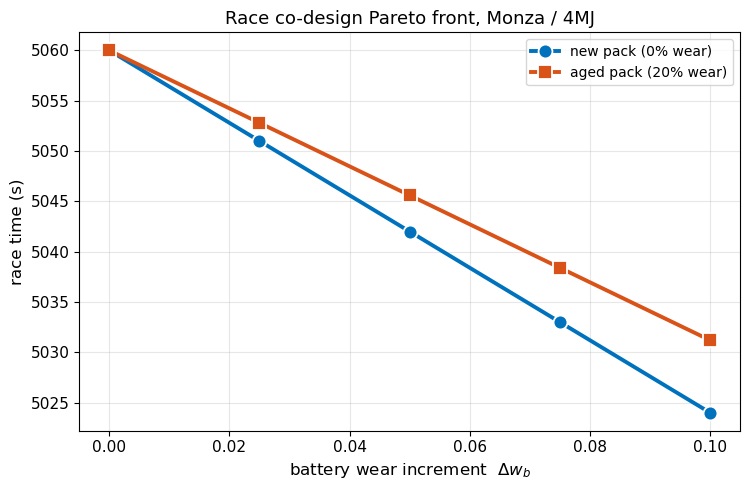

In [3]:
import matplotlib.pyplot as plt

BLUE, ORANGE = "#0072BD", "#D95319"

def front_xy(front):
    pts = sorted((p for _, p in front), key=lambda p: p['wear'])
    return [p['wear'] for p in pts], [p['race_time'] for p in pts]

xn, yn = front_xy(front_new)
xa, ya = front_xy(front_aged)

fig, ax = plt.subplots(figsize=(7.6, 5.0))
ax.plot(xn, yn, "-o", color=BLUE, lw=2.8, markersize=10, label="new pack (0% wear)",
        markeredgecolor="white", markeredgewidth=1.3)
ax.plot(xa, ya, "-s", color=ORANGE, lw=2.8, markersize=10, label="aged pack (20% wear)",
        markeredgecolor="white", markeredgewidth=1.3)
ax.set_xlabel("battery wear increment  $\\Delta w_b$", fontsize=12)
ax.set_ylabel("race time (s)", fontsize=12)
ax.set_title(f"Race co-design Pareto front, {track.name} / 4MJ", fontsize=13)
ax.legend(fontsize=10, frameon=True)
ax.grid(True, alpha=0.3, linewidth=0.8)
ax.tick_params(labelsize=11)
fig.tight_layout()
plt.show()


The aged pack sits above and to the left: with less usable energy it cannot reach the low race times a fresh pack can, no matter how hard it deploys. This is why incoming battery age is part of the DP state, and why the catalog is precomputed per age bucket.

## Reproducing the paper's figures (same format, illustrative numbers)

**Honest scope.** This section regenerates the paper's three key figures *in the same format*, so the framework's output can be compared side by side with the published ones. It does **not** reproduce the paper's numbers. The paper's fronts come from an optimal-control lap simulation and a battery-health degradation model that are not available here; the position model is fitted in the paper from a decade of FIA race data and the top-four constructors' results. What matches is the **structure**: the shape of the race-time-vs-wear Pareto fronts per (battery, age), the grid-position penalty curve with its saturation and track-difficulty ordering, and the finishing-position density. The numbers below are this example's stylised parameters. Treat this as proof that the framework produces the same *kind* of artefacts the paper reports, not as a numerical replication.

### Fig. 1: race Pareto fronts per (battery, initial age)

Race time on the x-axis (a tight band), wear increment in percent on the y-axis, one line per battery size and initial age (solid/dashed/dotted for 10/20/30% age), with the fastest point (node A, P1) and a representative trade-off (node B) highlighted, matching the paper's Fig. 1 layout.


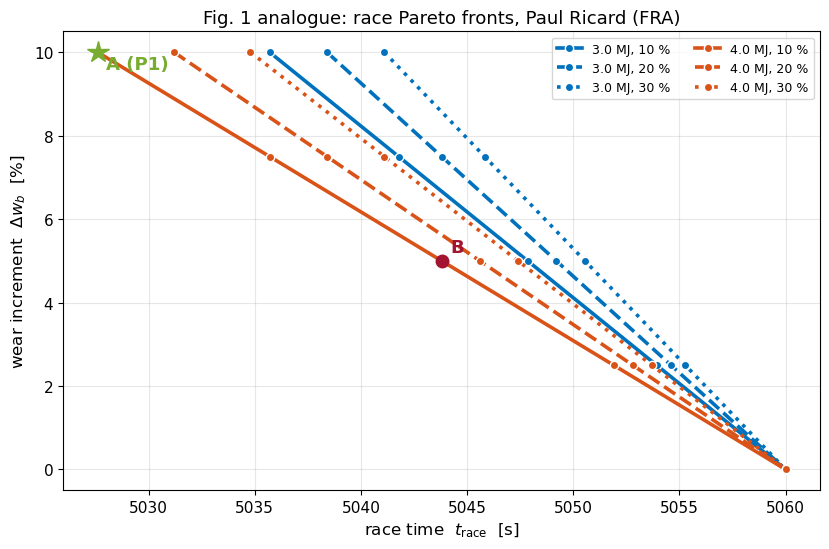

In [4]:
import matplotlib.pyplot as plt

fra = f1.Track("Paul Ricard (FRA)", base_time=5060.0, overtake_difficulty=0.4)
fig, ax = plt.subplots(figsize=(8.4, 5.6))
f1.figure1_race_fronts(fra, ax=ax)
fig.tight_layout()
plt.show()


The layout matches the paper's Fig. 1: two battery sizes, three initial-age curves each, race times clustered in a narrow band, wear on the vertical axis, and the highlighted fastest (A) and trade-off (B) nodes. The absolute time band and wear range differ from the paper (illustrative parameters), but the co-design produces exactly this family of nondominated fronts.

### Fig. 2: grid-start position penalty $\mu_{pos} \pm \sigma_{pos}$

The mean grid-start penalty as a function of the starting slot, with a $\pm\sigma$ band, for two tracks. The penalty is zero at the reference slot P3, a bonus for front starts, and saturates beyond ~P12; a hard-to-overtake track (Monaco) sits above an easy one, reproducing the paper's CAN-vs-MON ordering.


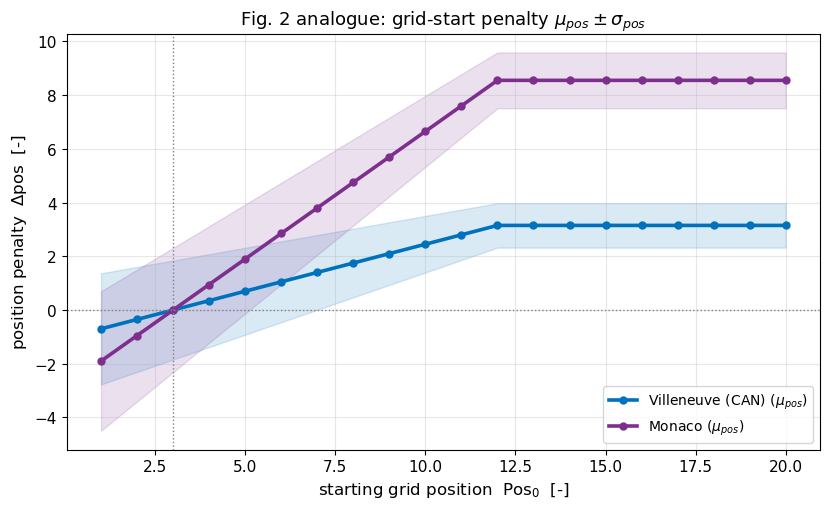

In [5]:
can = f1.Track("Villeneuve (CAN)", base_time=5100.0, overtake_difficulty=0.35)
mon = next(t for t in f1.SEASON if t.name == "Monaco")
fig, ax = plt.subplots(figsize=(8.4, 5.2))
f1.figure2_position_penalty([can, mon], ax=ax)
fig.tight_layout()
plt.show()


This reproduces the paper's Fig. 2 structure: the zero-crossing at the reference offset, the negative (bonus) region for strong starts, the saturation for poor starts, and Monaco penalising a bad grid slot more than Villeneuve, which is the whole point of the track-difficulty scaling.

### Fig. 3: finishing-position density $\varphi(\mathrm{Pos}_{\mathrm{end}})$

The density over finishing positions for the fastest implementation, for two starting slots (P3 and P6). A worse start shifts the distribution back, as in the paper's Fig. 3.


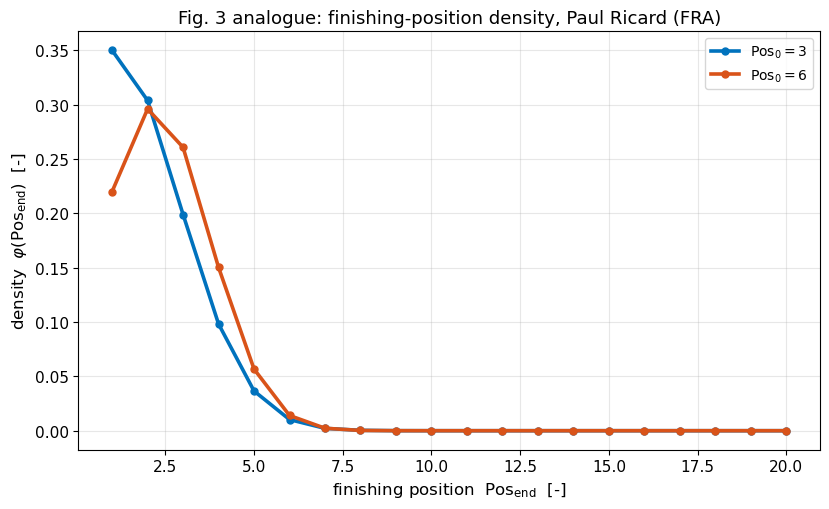

In [6]:
fig, ax = plt.subplots(figsize=(8.4, 5.2))
f1.figure3_finishing_distribution(fra, grid_starts=(3, 6), ax=ax)
fig.tight_layout()
plt.show()


The P3 curve peaks at P1 (consistent with the baseline offset) and the P6 curve shifts back, matching the paper's qualitative Fig. 3 behaviour. The exact shift is milder here because the stylised $\mu_{pos}$ is smaller than the paper's fitted value.

**Summary of the comparison.** All three figures reproduce the paper's *format and qualitative behaviour* from the framework's own co-design solves and position model. They are not a numerical match, and the notebook labels them as such. This is the honest sense in which the framework "does the same thing": it produces the same structured artefacts (Pareto fronts, penalty curves, finishing densities) that feed the same season-level dynamic program.

## Precompute every race front, once


In [7]:
catalogs = f1.precompute_race_catalogs(f1.SEASON)
print(f"{len(catalogs)} race fronts precomputed "
      f"({len(f1.SEASON)} tracks x {len(f1.BATTERIES)} batteries x "
      f"{len(f1.wear_buckets())} age buckets).")
print("These are frozen; the season DP below performs no further co-design solve.")


112 race fronts precomputed (8 tracks x 2 batteries x 7 age buckets).
These are frozen; the season DP below performs no further co-design solve.


## Layer 2: solve the season dynamic program

Backward induction over the season, carrying the `(w1, w2, ex)` state and maximising total expected championship points.


In [8]:
result = f1.solve_season(f1.SEASON, catalogs)
print(f"Optimal season expected points: {result.total_points:.1f}\n")
print(f"{'race':<12} {'unit':>4} {'batt':>5} {'deploy':>12} {'time':>8} "
      f"{'repl':>5} {'grid':>4} {'E[pts]':>6}")
for d in result.decisions:
    print(f"{d.track:<12} {d.battery_unit:>4} {d.battery_name:>5} "
          f"{d.deploy_name:>12} {d.race_time:>8.1f} "
          f"{'yes' if d.replaced else 'no':>5} {d.grid_start:>4} {d.exp_points:>6.1f}")


Optimal season expected points: 134.3

race         unit  batt       deploy     time  repl grid E[pts]
Monza           1   4MJ  deploy_1.00   5024.0   yes   13   15.7
Silverstone     1   4MJ  deploy_1.00   5087.6    no    3   17.6
Monaco          1   4MJ  deploy_1.00   5271.2    no    3   15.8
Spa             1   4MJ  deploy_1.00   5144.0   yes    8   16.0
Hungaroring     1   4MJ  deploy_1.00   5207.6    no    3   17.1
Suzuka          2   4MJ  deploy_1.00   5164.0    no    3   18.4
Interlagos      2   4MJ  deploy_1.00   5117.6    no    3   17.7
Zandvoort       1   4MJ  deploy_1.00   5191.2    no    3   15.9


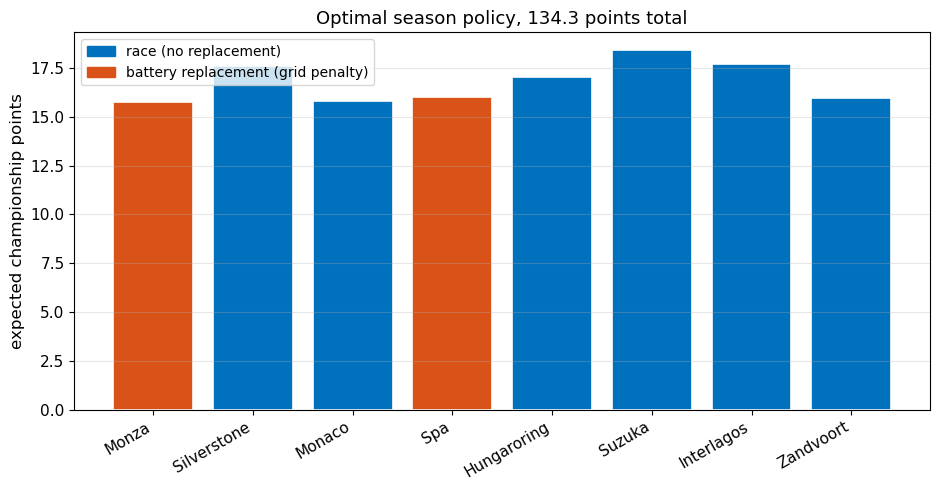

In [9]:
import numpy as np

races = [d.track for d in result.decisions]
pts = [d.exp_points for d in result.decisions]
repl = [d.replaced for d in result.decisions]
colors = [ORANGE if r else BLUE for r in repl]

fig, ax = plt.subplots(figsize=(9.5, 5.0))
bars = ax.bar(range(len(races)), pts, color=colors, edgecolor="white", linewidth=1.2)
ax.set_xticks(range(len(races)))
ax.set_xticklabels(races, rotation=30, ha="right", fontsize=10)
ax.set_ylabel("expected championship points", fontsize=12)
ax.set_title(f"Optimal season policy, {result.total_points:.1f} points total", fontsize=13)
ax.grid(True, axis="y", alpha=0.3, linewidth=0.8)
ax.tick_params(labelsize=11)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=BLUE, label="race (no replacement)"),
                   Patch(color=ORANGE, label="battery replacement (grid penalty)")],
          fontsize=10, frameon=True)
fig.tight_layout()
plt.show()


## Finding 1: a local penalty for a global gain

The optimal policy takes a battery replacement at one race, accepting a grid penalty (and a low points haul that day, the orange bar) to keep a fresh, low-wear pack available for aggressive deployment across the remaining races. Sacrificing points locally raises the season total, the multi-race coupling the paper highlights.


In [10]:
n_repl = sum(1 for d in result.decisions if d.replaced)
repl_races = [d.track for d in result.decisions if d.replaced]
print(f"replacements: {n_repl} at {repl_races}")
print(f"season total: {result.total_points:.1f} expected points")


replacements: 2 at ['Monza', 'Spa']
season total: 134.3 expected points


## Finding 2: race order shifts the optimal policy

The paper reports that race order does not change the attainable total reward but does change the optimal control policy. In this stylised model the grid-penalty cost is track-dependent (a replacement hurts far more at a hard-to-overtake track like Monaco than at Monza), so reordering the calendar lets the optimiser place the replacement on a cheaper track. The total is therefore *near*-invariant, and the policy adapts to the order, the temporal coupling of the multi-stage decision.


In [11]:
reversed_season = list(reversed(f1.SEASON))
rev_catalogs = f1.precompute_race_catalogs(reversed_season)
rev_result = f1.solve_season(reversed_season, rev_catalogs)

print(f"forward season total  = {result.total_points:.1f}")
print(f"reversed season total = {rev_result.total_points:.1f}  (near-invariant)")
print(f"forward replaces at  {[d.track for d in result.decisions if d.replaced] or 'never'}")
print(f"reversed replaces at {[d.track for d in rev_result.decisions if d.replaced] or 'never'}")
print("\nThe optimal replacement moves to a cheaper-penalty track under reordering,")
print("illustrating the temporal coupling the paper emphasises.")


forward season total  = 134.3
reversed season total = 134.8  (near-invariant)
forward replaces at  ['Monza', 'Spa']
reversed replaces at ['Spa', 'Monza']

The optimal replacement moves to a cheaper-penalty track under reordering,
illustrating the temporal coupling the paper emphasises.


## Correctness

The season DP is validated against exhaustive brute-force enumeration on small instances in `tests/test_formula1.py` (the DP's optimal value matches the brute-force optimum exactly, for both single- and mixed-battery unit configurations). The race co-design fronts are genuine MCDP solves, aged packs deploy less, and the catalogs are correctly indexed by incoming battery age. This is the precompute-then-DP structure of the F1 paper, with the co-design layer supplied by the framework and the season MDP written out as a scalar-maximisation backward induction.
